In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

from olimp.dataset.olimp import olimp
from olimp.dataset import read_img_path

In [6]:
!pip install git+https://github.com/pyolimp/pyolimp.git -q
!pip install scikit-image -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [7]:
# Загрузка датасета (5 картинок архитектуры)
# ============================================================
dataset = olimp(categories={"urban scenes/architecture"})

paths = dataset["urban scenes/architecture"][:6]  # 5 train + 1 test
print(f"Загружено путей: {len(paths)}")
print("Пример пути:", paths[0])


Output()

downloading dataset to /root/.cache/pyolimp/OLIMP

Загружено путей: 6
Пример пути: /root/.cache/pyolimp/OLIMP/OLIMP/urban scenes/architecture/iso-republic-angular-architecture-art.jpg


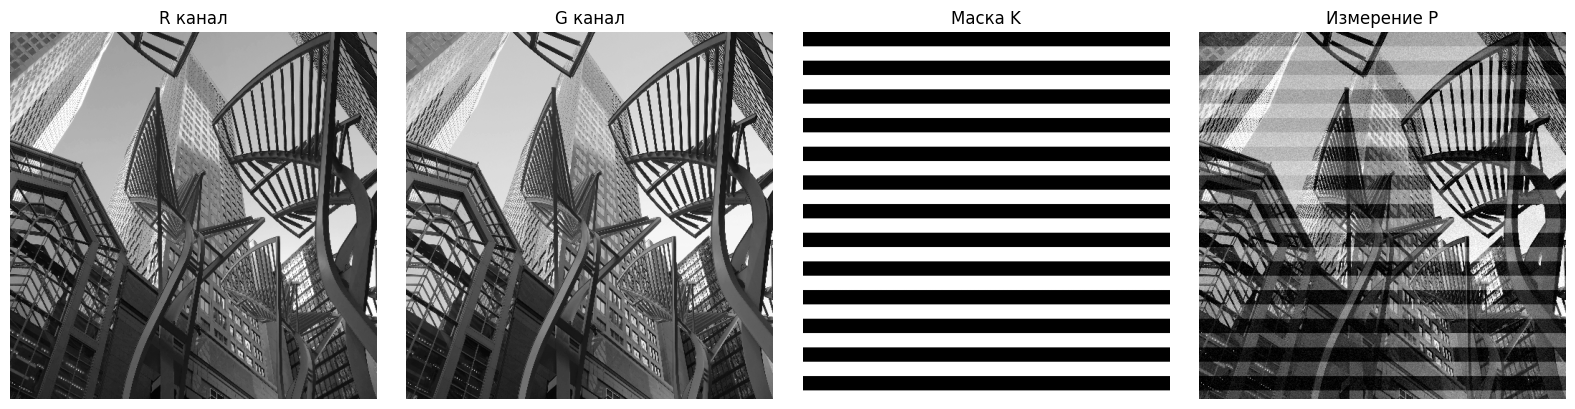

In [10]:
PATCH_SIZE = 128
STRIDE = 64
STRIPE_WIDTH = 20
SIGMA = 10 / 255.0

def load_rg(img_path):
    """Загрузить R и G каналы, нормализовать в [0,1], ресайз до 512x512"""
    img = read_img_path(img_path)
    img = np.transpose(img.numpy(), (1, 2, 0)) / 255.0
    img = cv2.resize(img, (512, 512))
    return img[:, :, :2].astype(np.float32)  # только R и G

def make_stripe_mask(h, w, stripe_width=STRIPE_WIDTH):
    """Горизонтальные полосы: 1 = зона R, 0 = зона G"""
    y = np.arange(h)
    K = ((y // stripe_width) % 2).astype(np.float32)
    return K[:, None] * np.ones((1, w), dtype=np.float32)

def make_measurement(rg, K):
    """
    Синтетическое измерение: P = K*R^0.7 + (1-K)*G^2 + шум
    Имитирует смешанный сигнал с разными нелинейностями в полосах
    """
    R = rg[:, :, 0]
    G = rg[:, :, 1]
    R = R / R.max()
    G = G / G.max()
    P = K * R ** 0.7 + (1 - K) * G ** 2
    noise = np.random.normal(0, SIGMA, P.shape).astype(np.float32)
    return np.clip(P + noise, 0, 1)

# Быстрая проверка — смотрим одно изображение
rg_sample = load_rg(paths[0])
K_sample = make_stripe_mask(512, 512)
P_sample = make_measurement(rg_sample, K_sample)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ["R канал", "G канал", "Маска K", "Измерение P"]
imgs = [rg_sample[:,:,0], rg_sample[:,:,1], K_sample, P_sample]
for ax, title, im in zip(axes, titles, imgs):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [11]:
# Dataset — нарезка на патчи с аугментацией
class StripeDataset(Dataset):
    def __init__(self, img_paths, patch_size=PATCH_SIZE, stride=STRIDE, augment=True):
        self.patches = []
        self.augment = augment

        for path in img_paths:
            rg = load_rg(path)
            H, W = rg.shape[:2]
            K = make_stripe_mask(H, W)
            P = make_measurement(rg, K)

            # Нарезаем изображение на патчи с перекрытием
            for y in range(0, H - patch_size + 1, stride):
                for x in range(0, W - patch_size + 1, stride):
                    self.patches.append((
                        P[y:y+patch_size, x:x+patch_size].copy(),
                        rg[y:y+patch_size, x:x+patch_size].copy(),
                        K[y:y+patch_size, x:x+patch_size].copy(),
                    ))

        print(f"Патчей для обучения: {len(self.patches)}")

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        P, rg, K = self.patches[idx]

        # Случайные отражения для разнообразия данных
        if self.augment:
            if np.random.rand() > 0.5:
                P, rg, K = np.fliplr(P).copy(), np.fliplr(rg).copy(), np.fliplr(K).copy()
            if np.random.rand() > 0.5:
                P, rg, K = np.flipud(P).copy(), np.flipud(rg).copy(), np.flipud(K).copy()

        # Вход: [P, K] — измерение + маска полос (сеть знает где полосы)
        inp = torch.tensor(np.stack([P, K], axis=0), dtype=torch.float32)
        # Цель: [R, G] — оба канала
        target = torch.tensor(np.transpose(rg, (2, 0, 1)), dtype=torch.float32)
        return inp, target

train_dataset = StripeDataset(paths[:5], augment=True)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

Патчей для обучения: 245


In [12]:
#Модель U-Net со skip connections

class ConvBlock(nn.Module):
    "Два свёрточных слоя с BatchNorm и ReLU"
    def __init__(self, in_ch, out_ch, dilation=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=dilation, dilation=dilation),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    """
    U-Net: энкодер сжимает → боттлнек с дилатацией (большое рецептивное поле)
    → декодер восстанавливает + skip connections сохраняют детали
    """
    def __init__(self, in_ch=2, out_ch=2):
        super().__init__()
        self.pool = nn.MaxPool2d(2)

        # Энкодер (сжатие)
        self.enc1 = ConvBlock(in_ch, 32)
        self.enc2 = ConvBlock(32, 64)
        self.enc3 = ConvBlock(64, 128)

        # Боттлнек: dilation=2 → видит контекст за пределами полосы 70px
        self.bot = ConvBlock(128, 256, dilation=2)

        # Декодер (восстановление)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = ConvBlock(256, 128)  # 256 = 128 upsampled + 128 skip
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = ConvBlock(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = ConvBlock(64, 32)

        self.out = nn.Conv2d(32, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.bot(self.pool(e3))

        # Skip connections: конкатенируем карты энкодера с декодером
        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Устройство: {device}")
print(f"Параметров в модели: {total_params:,}")

Устройство: cuda
Параметров в модели: 1,928,162


In [14]:
#  Функция потерь MSE + SSIM

class CombinedLoss(nn.Module):
    """
    MSE ловит попиксельные ошибки,
    SSIM штрафует за потерю структуры и контраста
    """
    def __init__(self, alpha=0.8):
        super().__init__()
        self.alpha = alpha
        self.mse = nn.MSELoss()

    def ssim_loss(self, pred, target):
        mu_p  = F.avg_pool2d(pred,   11, stride=1, padding=5)
        mu_t  = F.avg_pool2d(target, 11, stride=1, padding=5)
        sp    = F.avg_pool2d(pred**2,    11, stride=1, padding=5) - mu_p**2
        st    = F.avg_pool2d(target**2,  11, stride=1, padding=5) - mu_t**2
        spt   = F.avg_pool2d(pred*target,11, stride=1, padding=5) - mu_p*mu_t
        C1, C2 = 0.01**2, 0.03**2
        ssim_map = ((2*mu_p*mu_t + C1) * (2*spt + C2)) / \
                   ((mu_p**2 + mu_t**2 + C1) * (sp + st + C2))
        return 1 - ssim_map.mean()

    def forward(self, pred, target):
        return self.alpha * self.mse(pred, target) + (1 - self.alpha) * self.ssim_loss(pred, target)

criterion = CombinedLoss(alpha=0.8)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# Уменьшаем lr вдвое, если loss не падает 10 эпох
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=10, factor=0.5
)

Epoch   0/200  loss=0.0410  lr=0.00100
Epoch  25/200  loss=0.0381  lr=0.00100
Epoch  50/200  loss=0.0358  lr=0.00100
Epoch  75/200  loss=0.0298  lr=0.00050
Epoch 100/200  loss=0.0283  lr=0.00025
Epoch 125/200  loss=0.0277  lr=0.00025
Epoch 150/200  loss=0.0254  lr=0.00013
Epoch 175/200  loss=0.0257  lr=0.00006
Epoch 199/200  loss=0.0250  lr=0.00006


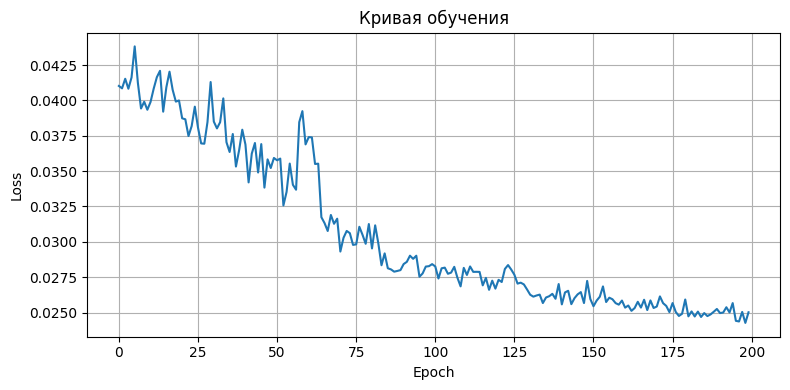

In [16]:
# Обучение

EPOCHS = 300
loss_history = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for inp, target in train_loader:
        inp, target = inp.to(device), target.to(device)
        optimizer.zero_grad()
        out  = model(inp)
        loss = criterion(out, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    scheduler.step(avg_loss)

    if epoch % 25 == 0 or epoch == EPOCHS - 1:
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d}/{EPOCHS}  loss={avg_loss:.4f}  lr={lr:.5f}")

# График обучения
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Кривая обучения")
plt.grid(True)
plt.tight_layout()
plt.show()


In [17]:
# Оценка на тестовом изображении

model.eval()

rg_test = load_rg(paths[5])
H, W = rg_test.shape[:2]
K_test = make_stripe_mask(H, W)
P_test = make_measurement(rg_test, K_test)

inp_test = torch.tensor(
    np.stack([P_test, K_test], axis=0), dtype=torch.float32
).unsqueeze(0).to(device)

with torch.no_grad():
    pred = model(inp_test).squeeze().cpu().numpy()

R_pred = np.clip(pred[0], 0, 1)
G_pred = np.clip(pred[1], 0, 1)
R_gt   = rg_test[:, :, 0]
G_gt   = rg_test[:, :, 1]

# Метрики
psnr_R = peak_signal_noise_ratio(R_gt, R_pred, data_range=1.0)
psnr_G = peak_signal_noise_ratio(G_gt, G_pred, data_range=1.0)
ssim_R = structural_similarity(R_gt, R_pred, data_range=1.0)
ssim_G = structural_similarity(G_gt, G_pred, data_range=1.0)

print(f"PSNR  R: {psnr_R:.2f} dB  |  G: {psnr_G:.2f} dB")
print(f"SSIM  R: {ssim_R:.4f}    |  G: {ssim_G:.4f}")

PSNR  R: 23.84 dB  |  G: 23.76 dB
SSIM  R: 0.8136    |  G: 0.8062


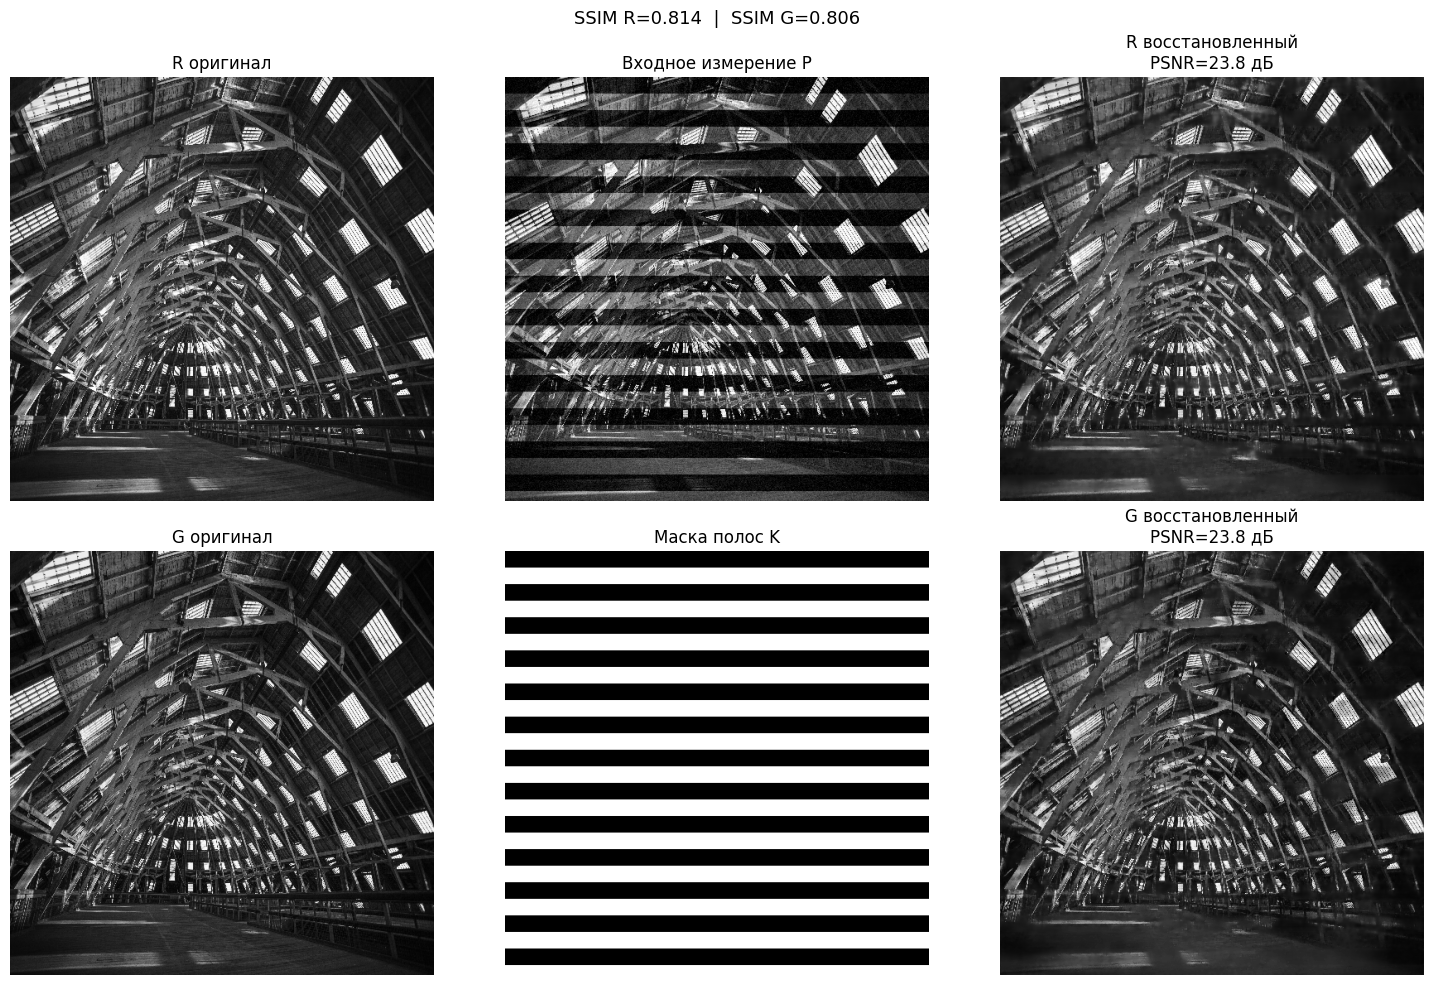

In [18]:
#  Визуализация результатов

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(R_gt,   cmap='gray'); axes[0, 0].set_title("R оригинал")
axes[0, 1].imshow(P_test, cmap='gray'); axes[0, 1].set_title("Входное измерение P")
axes[0, 2].imshow(R_pred, cmap='gray'); axes[0, 2].set_title(f"R восстановленный\nPSNR={psnr_R:.1f} дБ")

axes[1, 0].imshow(G_gt,   cmap='gray'); axes[1, 0].set_title("G оригинал")
axes[1, 1].imshow(K_test, cmap='gray'); axes[1, 1].set_title("Маска полос K")
axes[1, 2].imshow(G_pred, cmap='gray'); axes[1, 2].set_title(f"G восстановленный\nPSNR={psnr_G:.1f} дБ")

for ax in axes.flat:
    ax.axis("off")

plt.suptitle(f"SSIM R={ssim_R:.3f}  |  SSIM G={ssim_G:.3f}", fontsize=13)
plt.tight_layout()
plt.show()